In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.01 # In [fm^-2]
ENDING_RANGE_PARAMETER = 25
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 20 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

CENTRAL_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [3]:
def spin_orbit_term(tot_ang_momentum, orb_ang_momentum):
    return 0.5 * (tot_ang_momentum * (tot_ang_momentum + 1) - orb_ang_momentum * (orb_ang_momentum + 1) - 0.75)

def overlap_matrix_element(orb_ang_momentum, range_param_i, range_param_j):
    return ((2 * np.sqrt(range_param_i * range_param_j)) / (range_param_i + range_param_j))**(1.5 + orb_ang_momentum)

def potential_matrix_element(tot_ang_momentum, orb_ang_momentum, range_param_i, range_param_j, central_potential_mixing_coefficient,
                             central_potential_param, spin_orbit_potential_mixing_coefficient, spin_orbit_potential_param, theta, vls=V_LS):
    V_0 = -47.32 # Defines V_0 for odd and even l states, shifted from values in capel et. al.
    
    central_potential_term = V_0 * central_potential_mixing_coefficient * ((2 * np.sqrt(range_param_i * range_param_j) * np.exp(-2j * theta)) / (
        (range_param_i + range_param_j) * np.exp(-2j * theta) + central_potential_param))**(1.5 + orb_ang_momentum)
    #central_potential_term = V_0 * central_potential_mixing_coefficient * ((2 * np.sqrt(range_param_i * range_param_j)) / (
    #    range_param_i + range_param_j + central_potential_param))**(1.5 + orb_ang_momentum)

    spin_orbit_potential_term = -2 * spin_orbit_potential_mixing_coefficient * vls * spin_orbit_term(
        tot_ang_momentum, orb_ang_momentum) * spin_orbit_potential_param * ((
        2 * np.sqrt(range_param_i * range_param_j) * np.exp(-2j * theta)) / (
            np.exp(-2j * theta) * (range_param_i + range_param_j) + spin_orbit_potential_param))**(1.5 + orb_ang_momentum)
    #spin_orbit_potential_term = -2 * spin_orbit_potential_mixing_coefficient * vls * spin_orbit_term(
    #    tot_ang_momentum, orb_ang_momentum) * spin_orbit_potential_param * ((
    #    2 * np.sqrt(range_param_i * range_param_j)) / (spin_orbit_potential_param + range_param_i + range_param_j))**(
    #    1.5 + orb_ang_momentum)

    return central_potential_term - spin_orbit_potential_term

def kinetic_matrix_element(orb_ang_momentum, range_param_i, range_param_j, theta, μ=REDUCED_MASS):
    term_1 = 2 * orb_ang_momentum + 3
    term_2 = (range_param_i * range_param_j)**(1.75 + (orb_ang_momentum / 2))
    term_3 = (2 / (range_param_i + range_param_j))**(2.5 + orb_ang_momentum)

    return (197**2 / (2 * μ)) * term_1 * term_2 * term_3 * np.exp(-2j * theta)

def super_symmetric_potential_element(tot_ang_momentum, orb_ang_momentum, range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, spin_orbit_potential_mixing_coefficient, spin_orbit_potential_param, k_value,
                                      theta, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(tot_ang_momentum, orb_ang_momentum, range_param_i, range_param_j,
                                                       central_potential_mixing_coefficient,central_potential_param,
                                                       spin_orbit_potential_mixing_coefficient, spin_orbit_potential_param, theta)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(orb_ang_momentum, range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [27]:
def matrix_generation(tot_ang_momentum, orb_ang_momentum, theta, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = kinetic_matrix_element(orb_ang_momentum, i_range_parameter, j_range_parameter, theta)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += potential_matrix_element(tot_ang_momentum, orb_ang_momentum, i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k], spin_orbit_potential_mixing_coefficients[k],
                                                                 spin_orbit_potential_parameters[k], theta)
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = overlap_matrix_element(orb_ang_momentum, i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix


def susy_correction_mat_gen(tot_ang_momentum, orb_ang_momentum, k_value, theta, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = kinetic_matrix_element(orb_ang_momentum, i_range_parameter, j_range_parameter, theta)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += super_symmetric_potential_element(tot_ang_momentum, orb_ang_momentum, i_range_parameter,
                                                                           j_range_parameter, central_mixing_coefficients[k],
                                                                           central_potential_parameters[k], spin_orbit_potential_mixing_coefficients[k],
                                                                           spin_orbit_potential_parameters[k], k_value, theta)
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = overlap_matrix_element(orb_ang_momentum, i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix


def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [28]:
s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, 0)
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 323231233.3146981
The S state eigenvalues are [-1.15929743e+01  4.74118421e-01  1.97588470e+00  4.76324377e+00
  9.33801928e+00  1.65722483e+01  2.78901121e+01  4.54819342e+01
  7.26257647e+01  1.14278479e+02  1.78057217e+02  2.75777853e+02
  4.25726342e+02  6.56081505e+02  1.01056182e+03  1.55840380e+03
  2.41320237e+03  3.77268065e+03  6.02092227e+03  1.01137079e+04]
The S0 eigenvector is [[-6.62722384e-06+0.j -5.91679390e-04+0.j -5.91458772e-03+0.j
  -2.87518324e-02+0.j -7.64740473e-02+0.j -1.44322004e-01+0.j
  -2.07958914e-01+0.j -2.63348441e-01+0.j -2.41587246e-01+0.j
  -9.00345852e-02+0.j -6.65184883e-03+0.j -1.94725921e-04+0.j
   1.24786643e-04+0.j -7.25557532e-05+0.j  3.95170439e-05+0.j
  -2.02028701e-05+0.j  9.31051930e-06+0.j -3.59390648e-06+0.j
   1.01733921e-06+0.j -1.55076031e-07+0.j]]


In [29]:
def gauss_normalisation(range_param):
    return (2 / (np.pi * range_param))**(0.75)

def gauss_wavefunc(radius, range_param):
    return gauss_normalisation(range_param) * np.exp(- radius**2 / range_param**2)

def gauss_wavefunc_first_derivitave(radius, range_param):
    return - (2 * radius) / (range_param**2) * gauss_wavefunc(radius, range_param)

def gauss_wavefunc_second_derivitave(radius, range_param):
    return (2 / range_param) * (((1 * radius) / range_param**2) - 1) * gauss_wavefunc(radius, range_param)

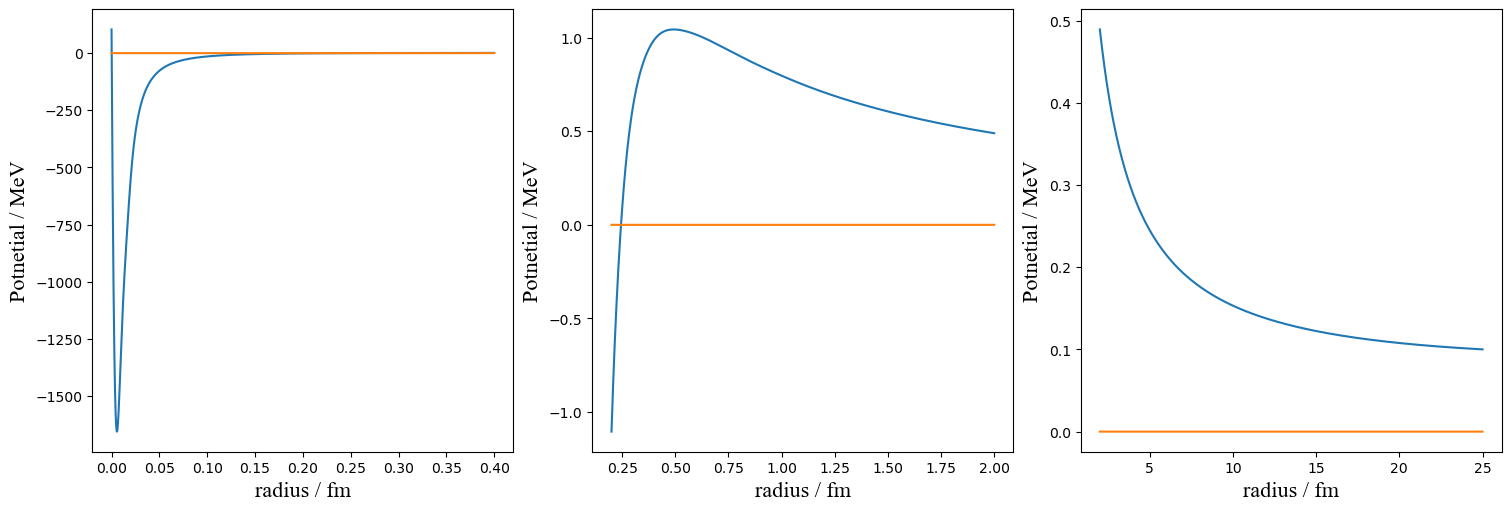

In [55]:
def susy_potential_plot_function(radius, mixing_coeffs, size=SUM_LIMIT):
    susy_vals = np.zeros(shape=(1, len(radius)))[0, :]
    mixing_coeffs = np.real(mixing_coeffs)
    for i in enumerate(radius):
        term_1 = 0
        term_2 = 0
        term_3 = 0
        for k in enumerate(mixing_coeffs):
            range_parameter = next_range_parameter(k[0])
            term_1 += gauss_wavefunc(i[1], range_parameter)
            term_2 += gauss_wavefunc_first_derivitave(i[1], range_parameter)
            term_3 += gauss_wavefunc_second_derivitave(i[1], range_parameter)
        susy_vals[i[0]] = -((term_3 / term_1) - (term_2 / term_1)**2)
    np.savetxt('name.txt', susy_vals)
    return susy_vals


r_vals = np.linspace(0, 0.4, 10000)
r_vals_2 = np.linspace(0.2, 2, 10000)
r_vals_3 = np.linspace(2, 25, 10000)
fig = plt.figure(figsize=(15, 5), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=1)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[0,2])

ax_1.plot(r_vals, susy_potential_plot_function(r_vals, s_eigenvectors[:, 0]))
ax_1.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_1.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_1.plot(r_vals, r_vals*0)

ax_2.plot(r_vals_2, susy_potential_plot_function(r_vals_2, s_eigenvectors[:, 0]))
ax_2.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_2.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_2.plot(r_vals_2, r_vals_2*0)

ax_3.plot(r_vals_3, susy_potential_plot_function(r_vals_3, s_eigenvectors[:, 0]))
ax_3.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_3.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_3.plot(r_vals_3, r_vals_2*0)



In [24]:
new_constrained_theta_values = np.linspace(0, 35 * np.pi / 180, 36)
new_constrained_p_one_half_eigen_matrix = np.zeros(shape=(len(new_constrained_theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(new_constrained_theta_values):
    p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, i[1])
    p_one_half_eigenvalues, d_five_half_eigenvectors = scipy.linalg.eig(p_one_half_h_matrix, p_one_half_n_matrix)
    new_constrained_p_one_half_eigen_matrix[i[0], :] = p_one_half_eigenvalues

new_constrained_p_three_half_eigen_matrix = np.zeros(shape=(len(new_constrained_theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(new_constrained_theta_values):
    p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, i[1])
    p_three_half_eigenvalues, p_three_half_eigenvectors = scipy.linalg.eig(p_three_half_h_matrix, p_three_half_n_matrix)
    new_constrained_p_three_half_eigen_matrix[i[0], :] = p_three_half_eigenvalues

In [ ]:
def straight_line_angle(x_vals, theta):
    # theta = 2 * theta * np.pi / 180
    return x_vals * np.tan(- 2 * theta)


x_vals = np.linspace(0, 10, 1000)

cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 36))
font_size_variable = 16
tick_size_variable = 12
legend_font = font_manager.FontProperties(family='Times New Roman',
                                          style='normal', size=14)

fig = plt.figure(figsize=(13, 5), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=1)
ax_1 = fig.add_subplot(spec[0, 0])
ax_2 = fig.add_subplot(spec[0, 1])

ax_1_title = (r'$\theta$ values $0^{\circ} \rightarrow 4^{\circ}$')

#print(new_constrained_d_five_half_eigen_matrix)

for i in enumerate(new_constrained_theta_values):
    ax_1.scatter(np.real(new_constrained_p_one_half_eigen_matrix[i[0], :]),
                 np.imag(new_constrained_p_one_half_eigen_matrix[i[0], :]), color=colors[i[0]], marker='x', s=100)
    if i[0] % 5 == 0:
        line_label_1 = fr'$\theta =${round(i[1] * 2 * 180 / np.pi)}'
        line_label_2 = r'$^\circ$'
        line_label = line_label_1 + line_label_2
        ax_1.plot(x_vals, straight_line_angle(x_vals, i[1]), label=line_label, color=colors[i[0]])
# label=(r'$\theta', f'= {i[1] * 180 / np.pi:.1f}', r'^{\circ}$'),
        
    
ax_1.set_xlim(left=0, right=6)
ax_1.set_ylim(bottom=-5, top=0.1)
ax_1.set_xlabel('Real Axis (Energy / MeV)', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_ylabel('Imaginary Axis', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.grid(color='darkslategrey', dashes=[6, 3, 6, 3])
ax_1.tick_params(axis='both', labelsize=tick_size_variable)
ax_1.legend(prop=legend_font)
ax_1.set_title('p1/2')


for i in enumerate(new_constrained_theta_values):
    ax_2.scatter(np.real(new_constrained_p_three_half_eigen_matrix[i[0], :]),
                 np.imag(new_constrained_p_three_half_eigen_matrix[i[0], :]), color=colors[i[0]], marker='x', s=100)
    if i[0] % 5 == 0:
        line_label_1 = fr'$\theta =${round(i[1] * 2 * 180 / np.pi)}'
        line_label_2 = r'$^\circ$'
        line_label = line_label_1 + line_label_2
        ax_2.plot(x_vals, straight_line_angle(x_vals, i[1]), label=line_label, color=colors[i[0]])
# label=(r'$\theta', f'= {i[1] * 180 / np.pi:.1f}', r'^{\circ}$'),
        
    
ax_2.set_xlim(left=0, right=6)
ax_2.set_ylim(bottom=-5, top=0.1)
ax_2.set_xlabel('Real Axis (Energy / MeV)', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_ylabel('Imaginary Axis', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.grid(color='darkslategrey', dashes=[6, 3, 6, 3])
ax_2.tick_params(axis='both', labelsize=tick_size_variable)
ax_2.legend(prop=legend_font)
ax_2.set_title('p3/2')



#plt.savefig('d_five_half_Complex_resonance_plot.png')

In [ ]:
theta_values = np.linspace(0, 0.59, 500)
p_one_half_eigenvalue_theta_matrix = np.zeros(shape=(len(theta_values), SUM_LIMIT), dtype=np.complex_)
p_three_half_eigenvalue_theta_matrix = np.zeros(shape=(len(theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(theta_values):
    p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, i[1])
    p_one_half_eigenvalues, p_one_half_eigenvectors = scipy.linalg.eig(p_one_half_h_matrix, p_one_half_n_matrix)
    p_one_half_eigenvalue_theta_matrix[i[0], :] = p_one_half_eigenvalues
    p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, i[1])
    p_three_half_eigenvalues, p_three_half_eigenvectors = scipy.linalg.eig(p_three_half_h_matrix, p_three_half_n_matrix)
    p_three_half_eigenvalue_theta_matrix[i[0], :] = p_three_half_eigenvalues

In [ ]:
fig = plt.figure(figsize=(15, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=1)
ax_1 = fig.add_subplot(spec[0, :])
#ax_2 = fig.add_subplot(spec[0, 1])

for i in enumerate(theta_values):
    ax_1.scatter(np.real(p_one_half_eigenvalue_theta_matrix[i[0], 17]),
                np.imag(p_one_half_eigenvalue_theta_matrix[i[0], 17]), c=(p_one_half_eigenvalue_theta_matrix[i[0], 17]), cmap='viridis')
ax_1.set_xlabel('Real Axis')
ax_1.set_ylabel('Imaginary Axis')
ax_1.set_title(r'$p_{1/2}$')
ax_1
plt.show()
plt.close()


In [ ]:
constrained_region_matrix = np.zeros(shape=(0, 2))

for i in enumerate(theta_values):
    for j in range(SUM_LIMIT):
        if 0.8 < np.real(p_one_half_eigenvalue_theta_matrix[i[0], j]) < 1.1 and -0.5 < np.imag(p_one_half_eigenvalue_theta_matrix[i[0], j]) < -0.2:
            constrained_region_matrix = np.append(constrained_region_matrix, p_one_half_eigenvalue_theta_matrix[i[0], j])

change_in_energy = np.zeros(shape=(1, len(constrained_region_matrix)-1))
for i in enumerate(change_in_energy[0, :]):
    change_in_energy[0, i[0]] = np.abs(constrained_region_matrix[i[0] + 1] - constrained_region_matrix[i[0]])
change_in_energy = change_in_energy[0, :]
print(f'Value where minimum change of energy occurs is at {constrained_region_matrix[np.where(change_in_energy == change_in_energy.min())]}')

fig = plt.figure(figsize=(15, 10), layout='constrained')
ax = fig.add_subplot()
#for i in enumerate(theta_values):
#    ax.scatter(np.real(p_one_half_eigenvalue_theta_matrix[i[0], :]),
#               np.imag(p_one_half_eigenvalue_theta_matrix[i[0], :]), marker='x', s=1, c=(p_one_half_eigenvalue_theta_matrix[i[0], :]), cmap='viridis')
ax.scatter(np.real(constrained_region_matrix),
            np.imag(constrained_region_matrix), marker='x', s=1, c='b')
#ax.scatter(1.274, -0.05, s = 100, c='r')
ax.plot(np.linspace(0.99350506, 0.99350506, 100), np.linspace(-0.5, 0.03, 100), label='Energy value of resonance')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
ax.set_title(r'$p_{1/2}$')
ax.set_xlim(left=0.8, right=1.1)
ax.set_ylim(bottom=-0.5, top=-0.3)
ax.legend()
#ax.set_xlim(left=1, right=2)
#ax.set_ylim(bottom=-2, top=0)
plt.savefig('Resonance_location.png')
plt.show()
plt.close()
